# Investigate Unassigned & Artifact_Spillover (UMAP + Leiden) — original postdoc code

**Reference copy** of the notebook the postdoc shared (`data.ipynb`), kept as-received for side-by-side comparison with `investigate_unassigned_spillover_umap.ipynb`.

That improved notebook splits this into multiple cells, adds docs/comments, and improves UMAP coloring. The analysis steps below are the same pipeline.

## What won't run as-is

The final plot uses `color=['group', 'leiden']`, but `../output/celldive_protein_matrix_celltypes.h5ad` has **`cell_type`**, not `group`. Scanpy raises `KeyError` for missing `group`.

Minimal fix (already applied in the improved notebook):

```python
sc.pl.umap(adata, color=['cell_type', 'leiden'], wspace=0.4)
```

Everything else (arcsinh → scale → PCA → neighbors → UMAP → Leiden) is unchanged from the postdoc's version.


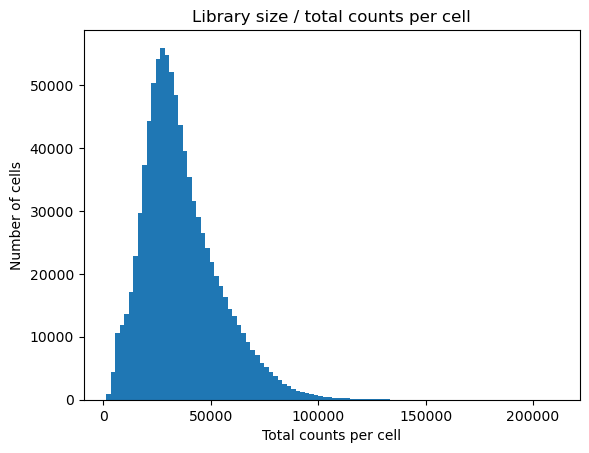

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
adata = sc.read_h5ad("../output/celldive_protein_matrix_celltypes.h5ad")

cell_sums = np.array(adata.X.sum(axis=1)).flatten()
plt.hist(cell_sums, bins=100)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Library size / total counts per cell")
plt.show()


In [2]:
cofactor = 150.0 # may need to be play around with value
adata.layers['raw'] = adata.X.copy()
adata.X = np.arcsinh(adata.X / cofactor)

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(20, adata.n_vars - 1)) # intensity vs markers (23-1 channels)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=['group', 'leiden'], wspace=0.4)


/tmp/ipykernel_787171/701133688.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


KeyError: 'Could not find key group in .var_names or .obs.columns.'

<Figure size 1792x480 with 0 Axes>

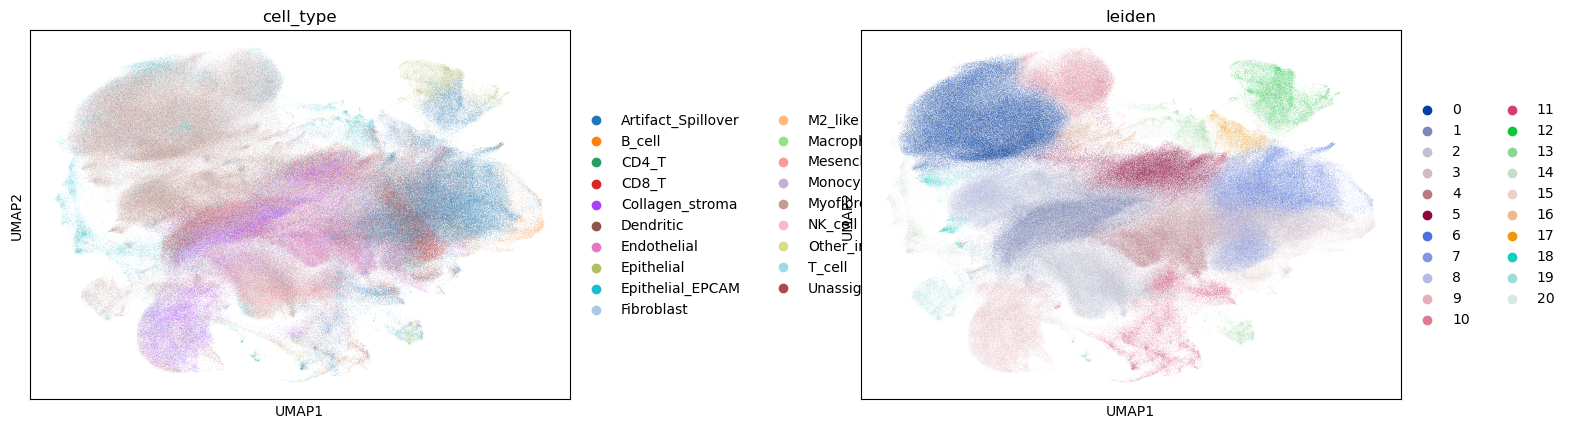

In [3]:
# Fix: this AnnData has `cell_type`, not `group`. UMAP/Leiden already finished above.
sc.pl.umap(adata, color=["cell_type", "leiden"], wspace=0.4)
